## Data Preprocessing

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# The dataset is from:
# https://www.kaggle.com/datasets/anikannal/solar-power-generation-data/

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "anikannal/solar-power-generation-data",
  'Plant_1_Generation_Data.csv',
  pandas_kwargs={'parse_dates': ['DATE_TIME'], 'index_col': 'DATE_TIME'}
)

df

c:\Users\cu\anaconda3\envs\test\Lib\site-packages\kagglehub\pandas_datasets.py:92: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  result = read_function(


,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
DATE_TIME,,,,,,
2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...
2020-06-17 23:45:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
2020-06-17 23:45:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
2020-06-17 23:45:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0


In [2]:
# Checking for missing data and basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 68778 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PLANT_ID     68778 non-null  int64  
 1   SOURCE_KEY   68778 non-null  object 
 2   DC_POWER     68778 non-null  float64
 3   AC_POWER     68778 non-null  float64
 4   DAILY_YIELD  68778 non-null  float64
 5   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 3.7+ MB


In [3]:
# Dropping the plant_id column as it is the same for all records
df.drop(columns=['PLANT_ID'], inplace=True)

# SOURCE_KEY might be useful in determining the inverter used for part anomaly detection

In [4]:
# Exploring the SOURCE_KEY column to see how many unique inverters are present
print("Unique SOURCE_KEY values:", df['SOURCE_KEY'].nunique())
df['SOURCE_KEY'].value_counts()

# There are 22 unique inverters in the dataset, with the data being roughly evenly distributed among them.

Unique SOURCE_KEY values: 22


SOURCE_KEY
bvBOhCH3iADSZry    3155
1BY6WEcLGh8j5v7    3154
VHMLBKoKgIrUVDU    3133
7JYdWkrLSPkdwr4    3133
ZnxXDlPa8U1GXgE    3130
ih0vzX44oOqAx2f    3130
z9Y9gH1T5YWrNuG    3126
wCURE6d3bPkepu2    3126
pkci93gMrogZuBj    3125
uHbuxQJl8lW7ozc    3125
iCRJl6heRkivqQ3    3125
rGa61gmuvPhdLxV    3124
McdE0feGgRqW7Ca    3124
zVJPv84UY57bAof    3124
sjndEbLyjtCKgGv    3124
ZoEaEvLYb1n2sOq    3123
zBIq5rxdHJRwDNY    3119
1IF53ai7Xc0U56Y    3119
adLQvlD726eNBSB    3119
3PZuoBAID5Wc2HD    3118
WRmjgnKYAwPKWDb    3118
YxYtjZvoooNbGkE    3104
Name: count, dtype: int64

<Axes: title={'center': 'AC and DC Power Generation Over Time'}, xlabel='DATE_TIME'>

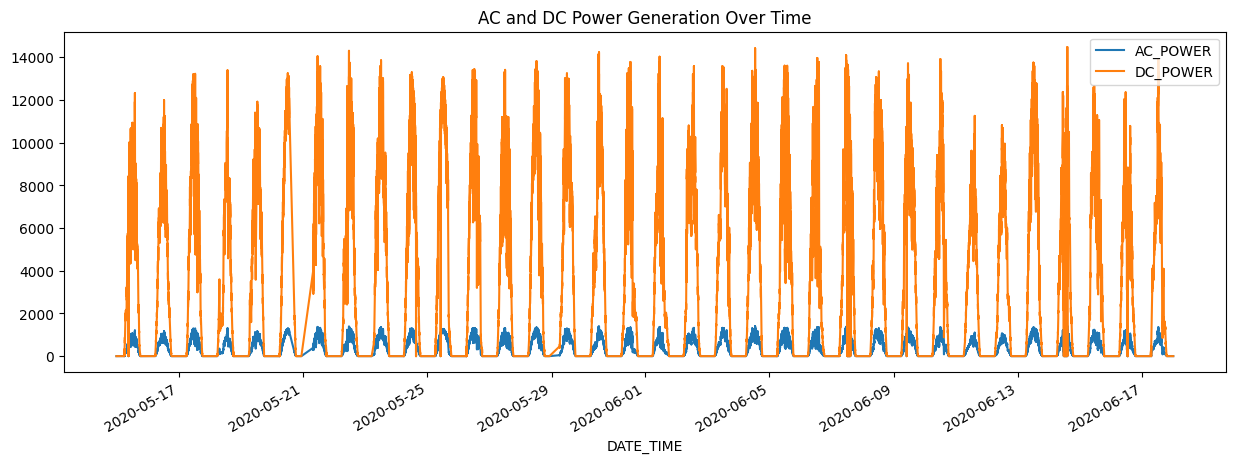

In [5]:
# Plotting overall data for AC and DC power generation
df.plot(y=['AC_POWER', 'DC_POWER'], figsize=(15, 5), title='AC and DC Power Generation Over Time')

# It can be noticed that for time series analysis,
# the data has seasonality which could suggest non-stationarity.

<Axes: title={'center': 'Average Day Power Generation Profile'}, xlabel='Time of Day', ylabel='Average Power (kW)'>

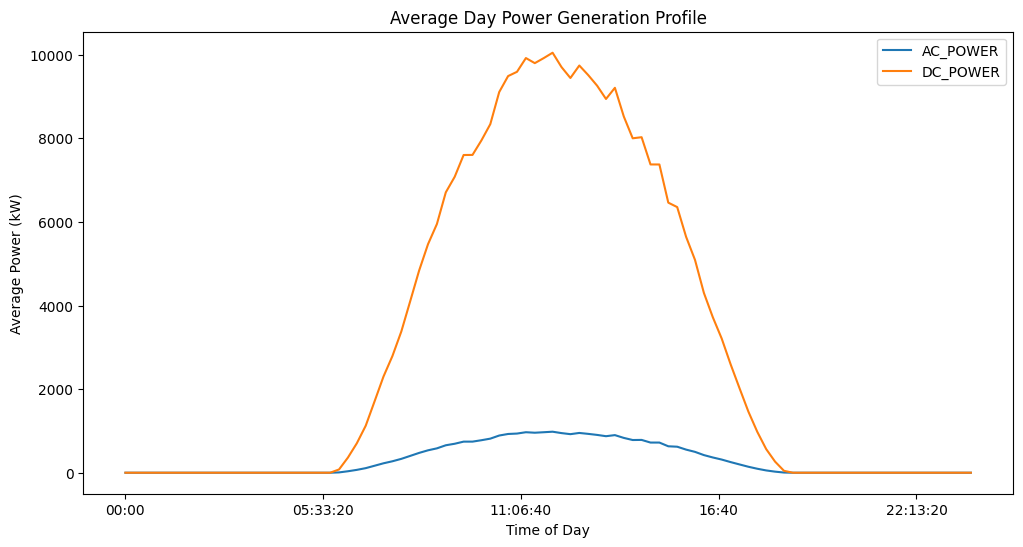

In [6]:
# Look at the 24-hour aggregated AC and DC power generation
avg_day = df.groupby(df.index.time)[['AC_POWER', 'DC_POWER']].mean()

avg_day.plot(
    figsize=(12, 6),
    title='Average Day Power Generation Profile',
    ylabel='Average Power (kW)',
    xlabel='Time of Day'
)

# It can be noticed that the power generation peaks at around 12:00 PM looking like a normal distribution.
# There is also a noticeable gap between AC and DC power generation, probably due to the inverter efficiency.

## Model Training

For the reasons of training, the target would be the AC_POWER since this is what we consume

The models were chosen as Parmezan et al. (2019) found them to be strong performers for time series forecasting. However, their study only looked at univariate data, so I'm extending this comparison for multivariate data.

Link to research: https://doi.org/10.1016/j.ins.2019.01.076

In [9]:
# Aggregating the inverter data to get a single plant-level time series
df_agg = df.groupby(df.index)[['AC_POWER', 'DC_POWER']].sum()
df_agg.index = pd.DatetimeIndex(df_agg.index)
df_agg = df_agg.asfreq('15min').ffill()

# Feature engineering: Adding time of day features using sine and cosine transformations
minutes = df_agg.index.hour * 60 + df_agg.index.minute
angle = 2 * np.pi * minutes / (24 * 60)

df_agg["TOD_SIN"] = np.sin(angle)
df_agg["TOD_COS"] = np.cos(angle)

# Scaling the AC and DC power generation data for better model performance
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df_agg.copy()

df_scaled[['AC_POWER', 'DC_POWER']] = scaler.fit_transform(
    df_scaled[['AC_POWER', 'DC_POWER']]
)

In [8]:
# Saving the scaler for later use in prediction
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [13]:
# Creating a windowed dataset for time series forecasting (SVR and LSTM)
def create_windowed_dataset(df, target_col, features, window_size, horizon=96):
    data = df[[target_col] + features].values
    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        window = data[i : i + window_size]  # shape: (window_size, n_features)
        target = data[i + window_size : i + window_size + horizon, 0]  # next horizon AC_POWER values
        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

X, y = create_windowed_dataset(
    df_scaled, target_col='AC_POWER', features=['DC_POWER', 'TOD_SIN', 'TOD_COS'],
    window_size=96, horizon=96  # predict the next full day at 15-min intervals
)

In [14]:
# Chronological split for time series
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

### Model 1: SVM

TODO: Retrain with additional features

In [10]:
# I used the cuml library to train the model on GPU for faster training and inference.
import cupy as cp
from cuml.svm import SVR
model = SVR()
model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
model.score(X_test.reshape(X_test.shape[0], -1), y_test)

# It can be noticed that the R2 score is 0.92 even in its base model

0.9236635767578397

In [13]:
# Performing hyperparameter tuning through GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    n_jobs=1,
    scoring='r2',
    verbose=3
)
grid_search.fit(X_train.reshape(X_train.shape[0], -1), y_train)
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Top CV MSE Score: {abs(grid_search.best_score_):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.919 total time=   0.8s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.916 total time=   0.5s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.922 total time=   0.5s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.922 total time=   0.5s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.919 total time=   0.6s
[CV 1/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.968 total time=  -1.8s
[CV 2/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.965 total time=   0.9s
[CV 3/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.971 total time=   0.9s
[CV 4/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.967 total time=   0.9s
[CV 5/5] END .C=0.1, gamma=scale, kernel=linear;, score=0.965 total time=   0.9s
[CV 1/5] END .....C=0.1, gamma=auto, kernel=rbf;, score=0.913 total time=   0.6s
[CV 2/5] END .....C=0.1, gamma=auto, kernel=rbf;

In [11]:
# Evaluating against test dataset
model = SVR(C=10,gamma='scale',kernel='linear')
model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
model.score(X_test.reshape(X_test.shape[0], -1), y_test)
# Score shows similarity with train, suggesting that the model is not overfitted
# Training time is taken from the hyperparameter tuning step,
# which is on average 29.74 secs.

0.9667131015453917

In [12]:
# Saving the model
import pickle

# Save
with open('svr_model.pkl', 'wb') as f:
    pickle.dump(model, f)
# The model size is 2.25 MB

### Model 2: LSTM

In [15]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [16]:
# Test if GPU is available
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [17]:
# Defining a dataset and data loader for the dataset
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,    # must be False for time series
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

In [18]:
# Defining a simple LSTM model for time series forecasting
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [19]:
def train_loop(dataloader, model, loss_fn, optimizer, scaler, device):
    size = len(dataloader.dataset)
    model.train()

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device, dtype=torch.float16, enabled=(device == "cuda")):
            pred = model(X)
            loss = loss_fn(pred, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if batch % 100 == 0:
            current = batch * len(X) + len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn, device):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test Error: Avg loss: {test_loss:>8f} \n")

In [ ]:
# Training the LSTM model with AMP

model = LSTMModel(input_size=4, hidden_size=24, num_layers=3, output_size=96).to(device)
loss_fn = nn.HuberLoss()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler(enabled=(device == "cuda"))
num_epochs = 100

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, opt, scaler, device)
    test_loop(test_loader, model, loss_fn, device)

print("Done!")
# Training took 43.5 secs.

Epoch 1
-------------------------------
loss: 0.059705  [   32/ 2458]
Test Error: Avg loss: 0.035621 

Epoch 2
-------------------------------
loss: 0.031758  [   32/ 2458]
Test Error: Avg loss: 0.022843 

Epoch 3
-------------------------------
loss: 0.015941  [   32/ 2458]
Test Error: Avg loss: 0.010533 

Epoch 4
-------------------------------
loss: 0.008607  [   32/ 2458]
Test Error: Avg loss: 0.008523 

Epoch 5
-------------------------------
loss: 0.006423  [   32/ 2458]
Test Error: Avg loss: 0.006950 

Epoch 6
-------------------------------
loss: 0.004791  [   32/ 2458]
Test Error: Avg loss: 0.005976 

Epoch 7
-------------------------------
loss: 0.003751  [   32/ 2458]
Test Error: Avg loss: 0.005569 

Epoch 8
-------------------------------
loss: 0.002960  [   32/ 2458]
Test Error: Avg loss: 0.005368 

Epoch 9
-------------------------------
loss: 0.002707  [   32/ 2458]
Test Error: Avg loss: 0.005278 

Epoch 10
-------------------------------
loss: 0.002741  [   32/ 2458]
Te

In [ ]:
# Evaluate the R2 score of the LSTM model on the test dataset
from sklearn.metrics import r2_score

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, dtype=torch.float32)
        pred = model(X).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(pred)

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

r2 = r2_score(y_true.reshape(-1), y_pred.reshape(-1))
print(r2)

# The R2 score is 0.87, which is lower

0.8724755048751831


In [ ]:
# Saving the best model for future use
torch.save(model.state_dict(), 'lstm_model.pth')
# The saved model is 62KB, which is small due to saving only the model weights and not the entire model architecture.

### Model 3: SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train/test split
split_idx = int(len(df_agg) * 0.8)

y_train = df_agg['AC_POWER'].iloc[:split_idx]
y_test = df_agg['AC_POWER'].iloc[split_idx:]

X_train = df_agg[['DC_POWER']].iloc[:split_idx]
X_test = df_agg[['DC_POWER']].iloc[split_idx:]

# Fit
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 96),
)

result = model.fit()

# Predict
y_pred = result.forecast(steps=len(y_test), exog=X_test)
# Training took 2 mins. 26 secs.

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train/test split
split_idx = int(len(df_agg) * 0.8)

y_train = df_agg['AC_POWER'].iloc[:split_idx]
y_test = df_agg['AC_POWER'].iloc[split_idx:]

X_train = df_agg[['DC_POWER']].iloc[:split_idx]
X_test = df_agg[['DC_POWER']].iloc[split_idx:]

# Fit
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 96),
)

result = model.fit()

# Predict
y_pred = result.forecast(steps=len(y_test), exog=X_test)
# Training took 2 mins. 26 secs.

In [13]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(r2)

# The R2 score is 0.99, which is the best among the three models

0.9999951795350396


In [ ]:
# Saving the best model for future use
result.save('sarimax_model.pkl')

# The saved model size is 13.4 GB

### Training Summary and Next Steps

Below are the metrics obtained for the three models:
| Model | Training time | R2 score | Model size |
| --- | --- | --- | --- |
| SVM | 29.74 secs. | 0.96 | 2.25 MB |
| LSTM | 43.5 secs. | 0.87 | 62 KB |
| SARIMAX | 2 mins. 26 secs. | 0.99 | 13.4 GB |

I decided to use the LSTM model as it has the lowest model size and training time among the three. A more rigorous way to select a model here would be through Pareto and Tradeoff Analysis.

Given that the model is a deep learning model, I want to perform optimizations and apply my learnings from this resource (https://hanlab.mit.edu/courses/2024-fall-65940)

In [24]:
# Loading the saved LSTM model
import torch
from torch import nn
from torch.utils.data import DataLoader

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out
model = LSTMModel(input_size=4, hidden_size=24, num_layers=3, output_size=96).to(device)
model.load_state_dict(torch.load('lstm_model.pth'))
model

LSTMModel(
  (lstm): LSTM(4, 24, num_layers=3, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=24, out_features=96, bias=True)
)

In [25]:
# Performing pruning on the LSTM model to reduce its size
import torch.nn.utils.prune as prune

parameters_to_prune = (
    (model.lstm, 'weight_ih_l0'),
    (model.lstm, 'weight_hh_l0'),
    (model.lstm, 'weight_ih_l1'),
    (model.lstm, 'weight_hh_l1'),
    (model.fc, 'weight'),
)

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.5, # Starting with 50% pruning
)
# Retraining the pruned model to recover any lost accuracy
loss_fn = nn.HuberLoss()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler(enabled=(device == "cuda"))
num_epochs = 50

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, opt, scaler, device)
    test_loop(test_loader, model, loss_fn, device)

print("Done!")

Epoch 1
-------------------------------
loss: 0.005176  [   32/ 2458]
Test Error: Avg loss: 0.005287 

Epoch 2
-------------------------------
loss: 0.002634  [   32/ 2458]
Test Error: Avg loss: 0.005044 

Epoch 3
-------------------------------
loss: 0.002540  [   32/ 2458]
Test Error: Avg loss: 0.004962 

Epoch 4
-------------------------------
loss: 0.002334  [   32/ 2458]
Test Error: Avg loss: 0.004927 

Epoch 5
-------------------------------
loss: 0.002273  [   32/ 2458]
Test Error: Avg loss: 0.004904 

Epoch 6
-------------------------------
loss: 0.002270  [   32/ 2458]
Test Error: Avg loss: 0.004901 

Epoch 7
-------------------------------
loss: 0.002357  [   32/ 2458]
Test Error: Avg loss: 0.004887 

Epoch 8
-------------------------------
loss: 0.002261  [   32/ 2458]
Test Error: Avg loss: 0.004873 

Epoch 9
-------------------------------
loss: 0.002260  [   32/ 2458]
Test Error: Avg loss: 0.004867 

Epoch 10
-------------------------------
loss: 0.002228  [   32/ 2458]
Te

In [ ]:
# Checking the R2 score of the pruned LSTM model on the test dataset
from sklearn.metrics import r2_score

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, dtype=torch.float32)
        pred = model(X).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(pred)

y_true = np.concatenate(y_true).ravel()
y_pred = np.concatenate(y_pred).ravel()

r2 = r2_score(y_true, y_pred)
print(r2)
# The R2 score is 0.86, which is the only 0.01 lower compared to the original LSTM model, 
# suggesting that pruning did not significantly affect the model's performance.

0.8688243627548218


In [27]:
# Saving the pruned model for reference
prune.remove(model.lstm, 'weight_ih_l0')
prune.remove(model.lstm, 'weight_hh_l0')
prune.remove(model.lstm, 'weight_ih_l1')
prune.remove(model.lstm, 'weight_hh_l1')
prune.remove(model.fc, 'weight')
torch.save(model.state_dict(), 'pruned_lstm_model.pth')

In [28]:
# Performing quantization on the pruned LSTM model to further reduce its size
from torchao.quantization import quantize_, Int8DynamicActivationInt8WeightConfig
quantize_(model, Int8DynamicActivationInt8WeightConfig())

W0706 14:57:59.318000 22892 site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
c:\Users\cu\anaconda3\envs\test\Lib\site-packages\torchao\dtypes\utils.py:89: UserWarning: Deprecation: PlainLayout is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
c:\Users\cu\anaconda3\envs\test\Lib\site-packages\torchao\dtypes\uintx\plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
c:\Users\cu\anaconda3\envs\test\Lib\site-packages\torchao\dtypes\affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and wi

In [29]:
# Evaluating the R2 score of the quantized pruned LSTM model on the test dataset
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, dtype=torch.float32)
        pred = model(X).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(pred)

y_true = np.concatenate(y_true).ravel()
y_pred = np.concatenate(y_pred).ravel()

r2 = r2_score(y_true, y_pred)
print(r2)

0.8690410256385803


In [30]:
torch.save(model.state_dict(), 'quantized_pruned_lstm_model.pth')

c:\Users\cu\anaconda3\envs\test\Lib\site-packages\torchao\dtypes\uintx\plain_layout.py:82: UserWarning: Deprecation: PlainAQTTensorImpl is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
c:\Users\cu\anaconda3\envs\test\Lib\site-packages\torchao\dtypes\affine_quantized_tensor.py:116: UserWarning: Deprecation: AffineQuantizedTensor is deprecated and will be removed in a future release of torchao, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(


## Validation Dataset

The [dataset](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data/?select=Plant_2_Generation_Data.csv) used contains a second CSV file for the second plant, which I would be using for the inference

In [2]:
# Getting the dataset for Plant 2
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "anikannal/solar-power-generation-data",
  'Plant_2_Generation_Data.csv',
  pandas_kwargs={'parse_dates': ['DATE_TIME'], 'index_col': 'DATE_TIME'}
)
df

,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
DATE_TIME,,,,,,
2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07
...,...,...,...,...,...,...
2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.000000,5.207580e+05
2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.000000,1.211314e+08
2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.000000,2.427691e+06


In [3]:
# Performing the same preprocessing as earlier
import joblib

scaler = joblib.load('scaler.pkl')

df_agg = df.groupby(df.index)[['AC_POWER', 'DC_POWER']].sum()
df_agg.index = pd.DatetimeIndex(df_agg.index)
df_agg = df_agg.asfreq('15min').ffill()

# Scaling the AC and DC power generation data for better model performance
df_scaled = df_agg.copy()
df_scaled[['AC_POWER', 'DC_POWER']] = scaler.transform(df_agg[['AC_POWER', 'DC_POWER']])

def create_windowed_dataset(df, target_col, features, window_size, horizon=96):
    data = df[[target_col] + features].values
    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        window = data[i : i + window_size]  # shape: (window_size, n_features)
        target = data[i + window_size : i + window_size + horizon, 0]  # next horizon AC_POWER values
        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

X, y = create_windowed_dataset(
    df_scaled, target_col='AC_POWER', features=['DC_POWER'],
    window_size=96, horizon=96  # predict the next full day at 15-min intervals
)

/home/nvidia/.venvs/rapids26.06_python3.12_cuda13/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# Saving the arrays for future use
np.save("X_val.npy", X)
np.save("y_val.npy", y)

In [5]:
import numpy as np
import json
import os
import joblib

# Load the scaler
scaler = joblib.load("scaler.pkl")

# Load the .npy files
X = np.load("X_val.npy")  # shape: (n_samples, 96, 2)
y = np.load("y_val.npy")  # shape: (n_samples, 96)

# Specify the number of samples to export
n_samples = 5

# Create output directory
output_dir = "samples"
os.makedirs(output_dir, exist_ok=True)

for i in range(n_samples):
    # Inverse-scale the target (AC_POWER)
    target_scaled = y[i]

    dummy = np.zeros((len(target_scaled), 2))
    dummy[:, 0] = target_scaled

    target_original = scaler.inverse_transform(dummy)[:, 0]

    sample = {
        "AC_POWER": X[i, :, 0].tolist(),
        "DC_POWER": X[i, :, 1].tolist(),
        "target": target_original.tolist()
    }

    with open(f"{output_dir}/sample_{i}.json", "w") as f:
        json.dump(sample, f, indent=2)

print(f"Saved {n_samples} files to ./{output_dir}/")

Saved 5 files to ./samples/


/home/nvidia/.venvs/rapids26.06_python3.12_cuda13/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
